# 01 EDA

This notebook covers only the exploratory data analysis for the IMDb sentiment dataset. All plots and observations are shown directly in the notebook; no output files are created.

In [1]:
from __future__ import annotations

import os
import random
import re
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.preprocess import clean_text, tokenize


In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")


In [3]:
dataset = load_dataset("imdb")
train_df = dataset["train"].to_pandas()
train_df["clean_text"] = train_df["text"].map(clean_text)
train_df["tokens"] = train_df["clean_text"].map(tokenize)
train_df["token_count"] = train_df["tokens"].map(len)
train_df.head()


,text,label,clean_text,tokens,token_count
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,i rented i am curious yellow from my video sto...,"[i, rented, i, am, curious, yellow, from, my, ...",287
1,"""I Am Curious: Yellow"" is a risible and preten...",0,i am curious yellow is a risible and pretentio...,"[i, am, curious, yellow, is, a, risible, and, ...",218
2,If only to avoid making this type of film in t...,0,if only to avoid making this type of film in t...,"[if, only, to, avoid, making, this, type, of, ...",89
3,This film was probably inspired by Godard's Ma...,0,this film was probably inspired by godard's ma...,"[this, film, was, probably, inspired, by, goda...",115
4,"Oh, brother...after hearing about this ridicul...",0,oh brother after hearing about this ridiculous...,"[oh, brother, after, hearing, about, this, rid...",309


## Class Distribution

In [4]:
class_counts = train_df["label"].value_counts().sort_index()
class_percentages = (class_counts / class_counts.sum() * 100).round(2)
pd.DataFrame({
    "label": ["negative", "positive"],
    "count": class_counts.values,
    "percentage": class_percentages.values,
})


,label,count,percentage
0,negative,12500,50.0
1,positive,12500,50.0


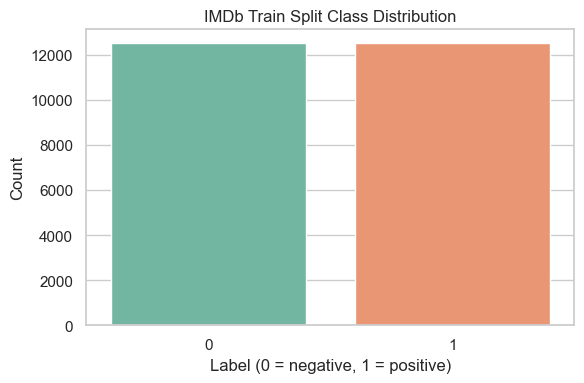

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="label", hue="label", palette="Set2", legend=False)
plt.title("IMDb Train Split Class Distribution")
plt.xlabel("Label (0 = negative, 1 = positive)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The training split is balanced, so accuracy will be easier to interpret and there is no strong class-imbalance concern at the EDA stage.

## Sequence Length Statistics

In [6]:
length_summary = {
    "min": int(train_df["token_count"].min()),
    "max": int(train_df["token_count"].max()),
    "mean": float(train_df["token_count"].mean()),
    "median": float(train_df["token_count"].median()),
    "p90": float(np.percentile(train_df["token_count"], 90)),
    "p95": float(np.percentile(train_df["token_count"], 95)),
}
pd.DataFrame([length_summary])


,min,max,mean,median,p90,p95
0,10,2462,232.38748,173.0,455.0,596.0


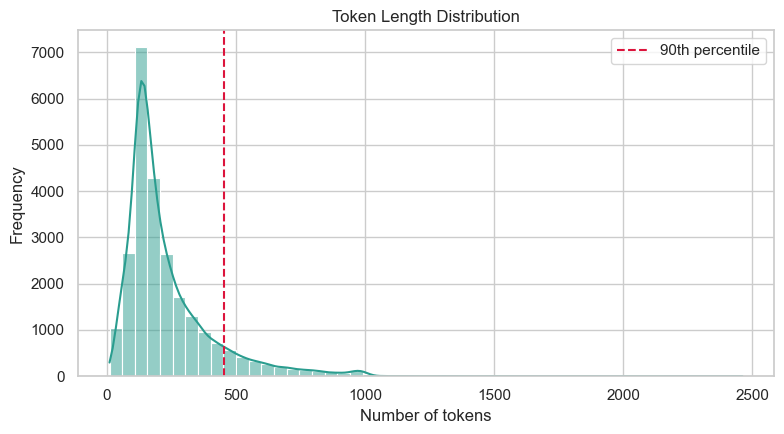

In [7]:
plt.figure(figsize=(8, 4.5))
sns.histplot(train_df["token_count"], bins=50, kde=True, color="#2a9d8f")
plt.axvline(length_summary["p90"], color="crimson", linestyle="--", label="90th percentile")
plt.title("Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


The 90th-percentile token count can be used later to justify a practical `max_len` for padding and truncation in the modeling notebooks.

## Vocabulary Frequency

In [8]:
token_counter = Counter(token for tokens in train_df["tokens"] for token in tokens)
top_30 = token_counter.most_common(30)
top_df = pd.DataFrame(top_30, columns=["token", "count"])
top_df


,token,count
0,the,336194
1,and,164131
2,a,163106
3,of,145851
4,to,135710
5,is,107319
6,in,93946
7,it,79128
8,i,77190
9,this,75977


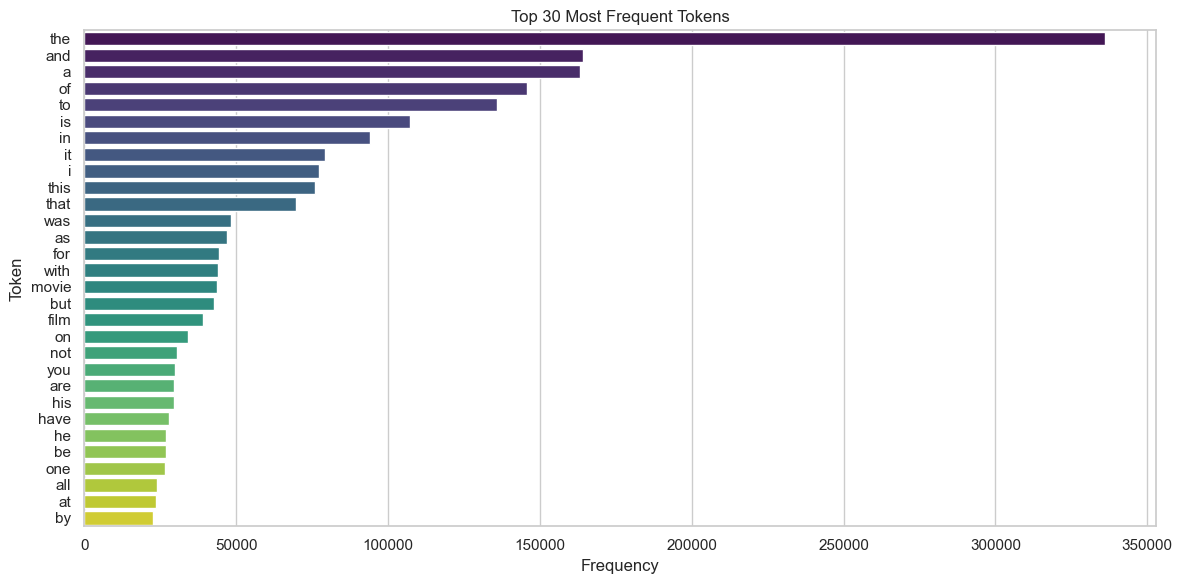

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_df, x="count", y="token", hue="token", palette="viridis", legend=False)
plt.title("Top 30 Most Frequent Tokens")
plt.xlabel("Frequency")
plt.ylabel("Token")
plt.tight_layout()
plt.show()


Frequent function words appear heavily in the vocabulary. That observation can motivate a discussion of stop-word removal, although sequence models often keep them because word order and local context still matter.

## Representative Samples

In [10]:
def show_samples(df: pd.DataFrame, label: int, n: int = 5) -> None:
    subset = df[df["label"] == label].head(n)
    for idx, row in subset.iterrows():
        print("-" * 100)
        print(row["clean_text"])
        print()

print("Positive examples")
show_samples(train_df, label=1, n=5)
print("Negative examples")
show_samples(train_df, label=0, n=5)


Positive examples
----------------------------------------------------------------------------------------------------
zentropa has much in common with the third man another noir like film set among the rubble of postwar europe like ttm there is much inventive camera work there is an innocent american who gets emotionally involved with a woman he doesn't really understand and whose naivety is all the more striking in contrast with the natives but i'd have to say that the third man has a more well crafted storyline zentropa is a bit disjointed in this respect perhaps this is intentional it is presented as a dream nightmare and making it too coherent would spoil the effect this movie is unrelentingly grim noir in more than one sense one never sees the sun shine grim but intriguing and frightening

----------------------------------------------------------------------------------------------------
zentropa is the most original movie i've seen in years if you like unique thrillers that are